# AgriWatch Monitor — anomalie suszy dla winnicy (Condom, Gers)
Otwieraj z GitHub (Plik → Otwórz → GitHub). Środowisko z **GPU** (dla SEN2SR). Potem `Uruchom wszystko`.

Łańcuch: Sentinel-2 (rastry, jak w v1) → SEN2SR 2,5 m z kontrolą → indeksy winnicy → anomalie (ERA5-Land SMA, SPI, NDVI)
→ status dekadowy wg logiki EDO CDI → walidacja na ISMN Condom → biuletyn i **dashboard winnicy**.
Wyniki: `MyDrive/GeoWorldLook/agriwatch/data/05_Final_Outputs/agriwatch/` i tabele `data/registry/gwl_*.csv`.


## 1. Dysk Google i kod z GitHub


In [9]:
import os, sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

REPO_URL = 'https://github.com/geoworldlook/1_geoworldlook-agriscreen.git'
PROJECT_DIR = '/content/drive/MyDrive/GeoWorldLook/agriwatch'
if IN_COLAB:
    if not os.path.exists(os.path.join(PROJECT_DIR, '.git')):
        os.makedirs(os.path.dirname(PROJECT_DIR), exist_ok=True)
        !git clone {REPO_URL} "{PROJECT_DIR}"
    # Lokalne zmiany w kodzie (np. zapisany notatnik) blokowały `pull --ff-only` i kod zostawał stary:
    # odkładamy je do stash (do odzyskania: git stash list / git stash pop), potem pull.
    !git -C "{PROJECT_DIR}" stash push -q -m "colab-autostash" || true
    !git -C "{PROJECT_DIR}" pull --ff-only
    !git -C "{PROJECT_DIR}" log -1 --format="Kod: %h %ci %s"
    if os.popen(f'git -C "{PROJECT_DIR}" rev-parse HEAD').read() != os.popen(f'git -C "{PROJECT_DIR}" rev-parse origin/main').read():
        print('[UWAGA] Kod na Dysku różni się od origin/main — wyniki będą z innej wersji kodu.')
else:
    PROJECT_DIR = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
import importlib
sys.modules.setdefault('imp', importlib)
try:
    %load_ext autoreload
    %autoreload 2
except Exception as e:
    print(f'[INFO] autoreload pominięty ({e})')
print('Projekt:', PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 16 (delta 10), reused 8 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 225.69 KiB | 106.00 KiB/s, done.
From https://github.com/geoworldlook/1_geoworldlook-agriscreen
   7f73dfb..f668b6c  main       -> origin/main
   7f73dfb..f668b6c  claude/charming-franklin-c4i0k3 -> origin/claude/charming-franklin-c4i0k3
Updating 7f73dfb..f668b6c
Fast-forward
 docs/plans/Plan_v7_precyzja.md    |   12 +
 notebooks/AgriWatch_Monitor.ipynb | 1210 +++++++++++++++++++++++++++++++++++--
 step_05_colab_run.py              |   11 +-
 step_06_dashboard.py              |   47 +-
 step_08_weather.py                |   60 +-
 5 files changed, 1276 insertions(+), 64 deletions(-)
Kod: f668b6c 2026-10-09 08:30:08 +0000 fix(w

## 2. Środowisko: pakiety, GEE, rejestr, konfiguracja


In [10]:
from step_05_colab_run import (setup_runtime, monitor_config, run_task, run_history, registry_summary,
                               task_ingest_s2, task_ingest_era5, task_scene_stats, task_anomalies,
                               task_validate, task_weather, task_bulletin, task_dashboard, task_summary)
from step_06_dashboard import show_dashboard
rt = setup_runtime(PROJECT_DIR, gee_project='ee-geoworldlook', pull=False)
cfg = monitor_config(rt)   # zmiany: monitor_config(rt, {'VINEYARDS': {'VINEYARD_06': 6, 'VINEYARD_07': 7}})


## 3. Dane: rastry Sentinel-2 (przyrostowo) i ERA5-Land 1991 → dziś


In [11]:
run_task(rt, 'ingest_s2', task_ingest_s2, rt, cfg)
run_task(rt, 'ingest_era5', task_ingest_era5, rt, cfg)


[SKIPPED] ingest_s2 (3.3 s) 414 scen na Dysku, 0 nowych
[OK] ingest_era5 (1.0 s) 


{'message': 'ERA5-Land: 13058 dni do 2026-10-01'}

## 4. Indeksy winnicy i stacji: 10 m oraz SEN2SR 2,5 m (kontrola H-SR0/H-SR1, bez zastępstwa interpolacją)


In [ ]:
run_task(rt, 'scene_stats', task_scene_stats, rt, cfg)


[SKIPPED] scene_stats (1.9 s) 10 m: 0 nowych scen; SR: 0 scen, NDVI 2,5 m przyjęte w 0, NDMI 2,5 m w 0, CRSWIR 2,5 m w 0 (próg 20 m: specyfikacja L2A × 1.5); pokrycie SR (detekcja): 414/414 scen przetworzonych, 399 przyjętych, 0 w kolejce


{'skipped': True,
 'message': '10 m: 0 nowych scen; SR: 0 scen, NDVI 2,5 m przyjęte w 0, NDMI 2,5 m w 0, CRSWIR 2,5 m w 0 (próg 20 m: specyfikacja L2A × 1.5); pokrycie SR (detekcja): 414/414 scen przetworzonych, 399 przyjętych, 0 w kolejce',
 'registry': {}}

## 5. Anomalie, status, walidacja, przymrozki i upały, biuletyn
`weather`: dane dobowe Météo-France (Gers, Lot-et-Garonne) i ERA5-Land w punktach najbliższych stacji — walidacja
Tmin, Tmax, opadu i SPI oraz kalibracja progów przymrozku i upału. Pierwsze uruchomienie pobiera ERA5 dla stacji
(kilka minut), kolejne korzystają z cache.


In [12]:
run_task(rt, 'anomalies', task_anomalies, rt, cfg)
run_task(rt, 'validate', task_validate, rt, cfg)
run_task(rt, 'weather', task_weather, rt, cfg)
run_task(rt, 'bulletin', task_bulletin, rt, cfg)


[OK] anomalies (4.9 s) gwl_anomalies: +0/~0, gwl_status: +0/~0
[OK] validate (12.4 s) gwl_validation_metrics: +0/~0
[OK] weather (24.5 s) gwl_validation_metrics: +12/~0
[OK] bulletin (5.0 s) 


{'message': 'data/05_Final_Outputs/agriwatch/agriwatch_latest.json, data/05_Final_Outputs/agriwatch/bulletin.md, data/05_Final_Outputs/agriwatch/season_2022.png, data/05_Final_Outputs/agriwatch/last_12_months.png, data/05_Final_Outputs/agriwatch/last_5_years.png'}

## 6. Dashboard winnicy
Mapa NDVI na zdjęciu satelitarnym (wybór daty), status, ryzyko suszy, przyczyny, pogoda i prognoza, wiarygodność.
Plik: `data/05_Final_Outputs/agriwatch/dashboard.html` (można otworzyć w przeglądarce z Dysku).


[OK] dashboard (1.0 s) 



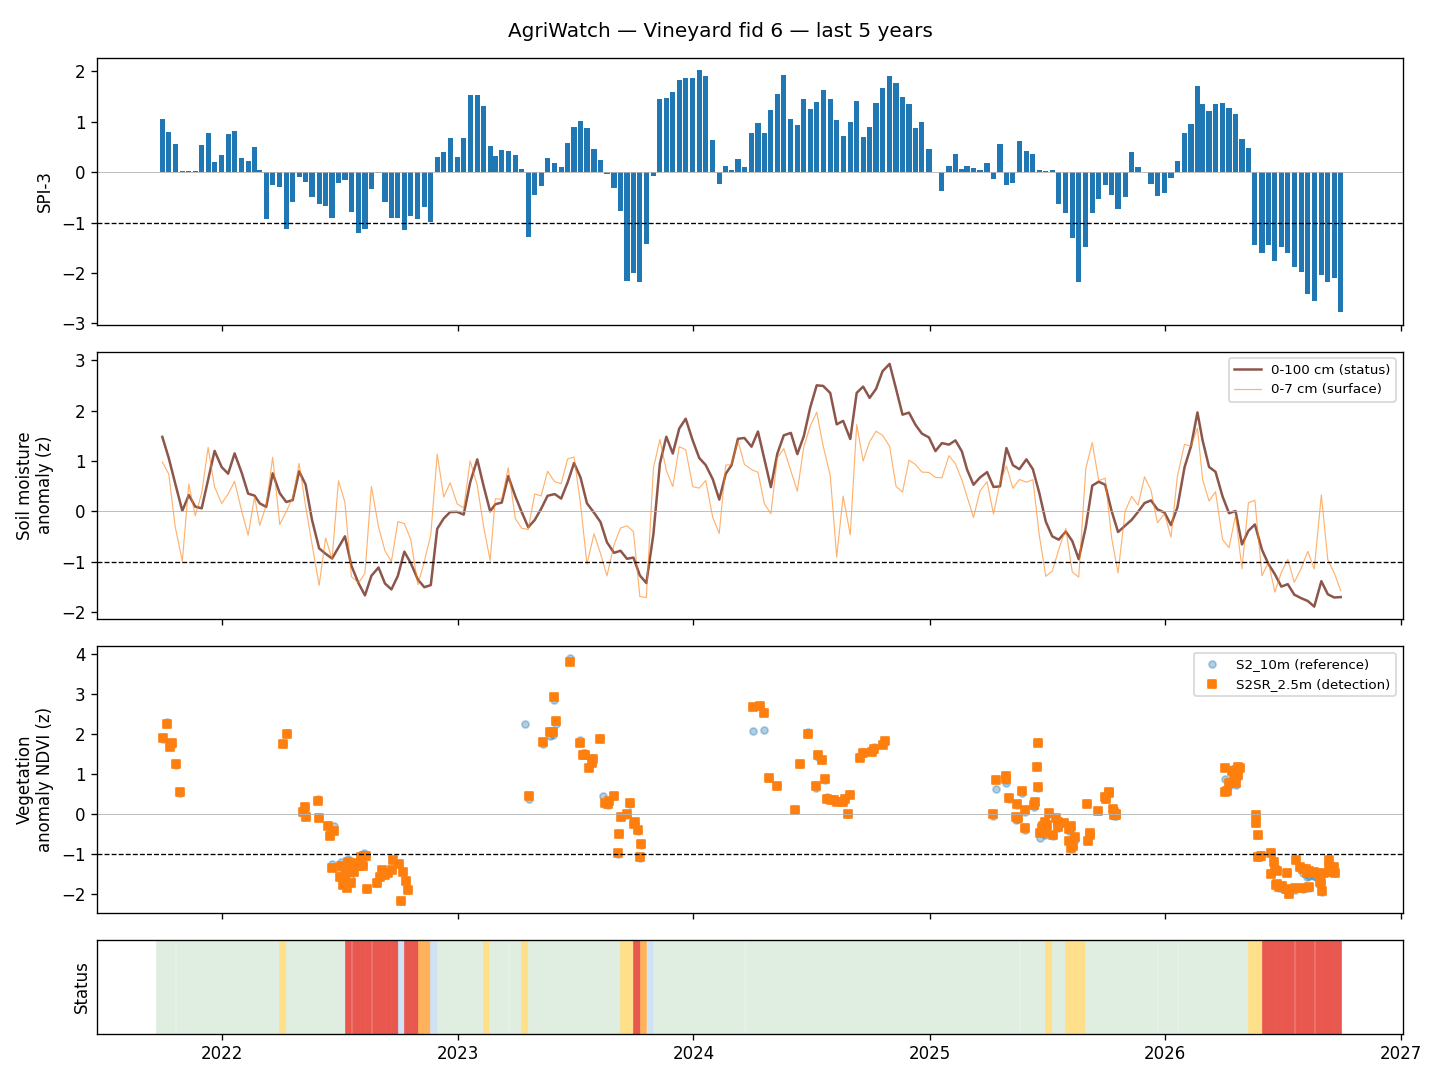

In [14]:
run_task(rt, 'dashboard', task_dashboard, rt, cfg)
p = os.path.join(cfg['OUTPUT_DIR'], 'dashboard.html')
if os.path.exists(p):
    show_dashboard(p)
else:
    print('Dashboard nie powstał — sprawdź komunikat zadania powyżej.')


## 7. Raport z uruchomienia (do analizy)
`run_summary.md` — wersje, konfiguracja, pokrycie danych, kontrola SR, status per rok, walidacja, błędy.
**Po każdym większym uruchomieniu prześlij ten plik** (albo wklej jego treść) — na nim opieramy wnioski.


In [15]:
run_task(rt, 'summary', task_summary, rt, cfg)
print(open(os.path.join(cfg['OUTPUT_DIR'], 'run_summary.md'), encoding='utf-8').read())


[OK] summary (0.5 s) 
# AgriWatch — raport z uruchomienia 2026-10-09T08:41:39Z

Commit `f668b6c+dirty` · urządzenie: cpu · sen2sr 0.8.5 · torch 2.11.0+cpu

## Dane
{"s2_scenes": 414, "s2_first": "20160411", "s2_last": "20261006", "era5_last_day": "2026-10-01"}

## Konfiguracja
{"MAIN_SITE": "VINEYARD_06", "VEG_PRODUCT": "S2SR_2.5m", "VEG_INDEX": "ndvi", "S2_MONTHS": [4, 10], "S2_CLOUD_MAX_AOI": 40, "THR_SPI1": -2.0, "THR_SPI3": -1.0, "THR_SMA": -1.0, "THR_VEG": -1.0, "SR_MAX_CONSISTENCY_RMSE": 0.01, "SR_20M_SPEC_FACTOR": 1.5, "SR_MIN_DETAIL_RATIO": 0.02, "SR_MAX_SCENES_PER_RUN": 150}

## Super-resolution (kontrola qc4)
| zmienna | wartość | accept_rate | median | p90 |
|---|---|---|---|---|
| qc_version | qc4 |  |  |  |
| scenes_checked | 414 |  |  |  |
| scenes | 414 |  |  |  |
| sr_done | 414 |  |  |  |
| sr_ok |  | 0.964 |  |  |
| remaining | 0 |  |  |  |
| consistency_rmse_max |  |  | 0.0034 | 0.0042 |
| consistency_rmse_max_20m |  |  | 0.0184 | 0.0237 |
| crswir_sr_err |  |  | 0.0

## 8. Rejestr i historia uruchomień


In [16]:
display(registry_summary(rt))
display(run_history(rt, n=10))


,table,rows,size_kb
0,gwl_sites,3,2.2
1,gwl_observations,38883,5257.6
2,gwl_anomalies,6833,1003.5
3,gwl_validation_metrics,389,60.2
4,gwl_calibrations,17,2.3
5,gwl_status,1161,264.6
6,gwl_runs,94,70.3


,run_id,task,status,duration_s,n_new_rows,git_commit,message
0,20261009T084138Z_summary,summary,ok,0.5,0,f668b6c+dirty,NaN
1,20261009T084118Z_dashboard,dashboard,ok,1.0,0,f668b6c+dirty,NaN
2,20261009T084041Z_dashboard,dashboard,ok,2.4,0,f668b6c+dirty,NaN
3,20261009T084036Z_bulletin,bulletin,ok,5.0,0,f668b6c+dirty,NaN
4,20261009T084011Z_weather,weather,ok,24.5,12,f668b6c+dirty,gwl_validation_metrics: +12/~0
5,20261009T083959Z_validate,validate,ok,12.4,0,f668b6c+dirty,gwl_validation_metrics: +0/~0
6,20261009T083954Z_anomalies,anomalies,ok,4.9,0,f668b6c+dirty,"gwl_anomalies: +0/~0, gwl_status: +0/~0"
7,20261009T083946Z_ingest_era5,ingest_era5,ok,1.0,0,f668b6c+dirty,NaN
8,20261009T083943Z_ingest_s2,ingest_s2,skipped,3.3,0,f668b6c+dirty,"414 scen na Dysku, 0 nowych"
9,20261009T075544Z_summary,summary,ok,4.8,0,7f73dfb+dirty,NaN
